1. Introduction
Mental health issues, particularly depression, are increasingly prevalent among students due to academic pressure, financial stress, and lifestyle habits. This project aims to analyze the factors contributing to student depression and predict depression likelihood using machine learning models. By leveraging data-driven insights, the project intends to identify key predictors of depression and provide actionable insights for early intervention strategies.

The goals of the project are as follows:

Understand the relationship between various factors such as academic pressure, sleep duration, and dietary habits with depression.
Build predictive models to classify students into depressed or non-depressed categories.
Provide recommendations for improving mental health among students based on data analysis.
This study highlights the significance of mental health and aims to contribute to building a supportive environment for students by utilizing artificial intelligence.



2. Dataset Overview
Number of Features:

Total Data: (27901)
columns: 18

Problem Type:

This is a classification problem because the target variable, "Depression," is categorical, representing whether a student is depressed (1) or not depressed (0).

Number of Data Points:
27901
Types of Features:

Quantitative Features: Continuous numerical data, e.g., CGPA, Work/Study Hours.
Categorical Features: Gender, Dietary Habits, Degree.

In [145]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [146]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [191]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [147]:
df= pd.read_csv(r'/content/Student Depression - Student Depression Dataset.csv')

In [148]:
df.shape

(27901, 18)

In [149]:
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33,Visakhapatnam,Student,5.0,0,8.97,2.0,0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24,Bangalore,Student,2.0,0,5.90,NaN,0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31,Srinagar,Student,3.0,0,7.03,5.0,0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28,Varanasi,Student,3.0,0,5.59,2.0,0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25,Jaipur,Student,4.0,0,8.13,3.0,0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [150]:
df.tail()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
27896,140685,Female,27,Surat,Student,5.0,0,5.75,NaN,0,5-6 hours,Unhealthy,Class 12,Yes,7.0,1.0,Yes,0
27897,140686,Male,27,Ludhiana,Student,2.0,0,9.40,3.0,0,Less than 5 hours,Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31,Faridabad,Student,3.0,0,6.61,4.0,0,5-6 hours,Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18,Ludhiana,Student,5.0,0,NaN,2.0,0,Less than 5 hours,Healthy,Class 12,Yes,NaN,5.0,No,1
27900,140699,Male,27,Patna,Student,4.0,0,9.24,NaN,0,Less than 5 hours,Healthy,BCA,Yes,2.0,3.0,Yes,1


In [151]:
df.isnull().sum()

,0
id,0
Gender,0
Age,0
City,0
Profession,0
Academic Pressure,42
Work Pressure,0
CGPA,42
Study Satisfaction,68
Job Satisfaction,0


In [152]:
df.columns.tolist()

['id',
 'Gender',
 'Age',
 'City',
 'Profession',
 'Academic Pressure',
 'Work Pressure',
 'CGPA',
 'Study Satisfaction',
 'Job Satisfaction',
 'Sleep Duration',
 'Dietary Habits',
 'Degree',
 'Have you ever had suicidal thoughts ?',
 'Work/Study Hours',
 'Financial Stress',
 'Family History of Mental Illness',
 'Depression']

In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  int64  
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27859 non-null  float64
 6   Work Pressure                          27901 non-null  int64  
 7   CGPA                                   27859 non-null  float64
 8   Study Satisfaction                     27833 non-null  float64
 9   Job Satisfaction                       27901 non-null  int64  
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [154]:
df = df.drop(['id'], axis = 1)
df.shape

(27901, 17)

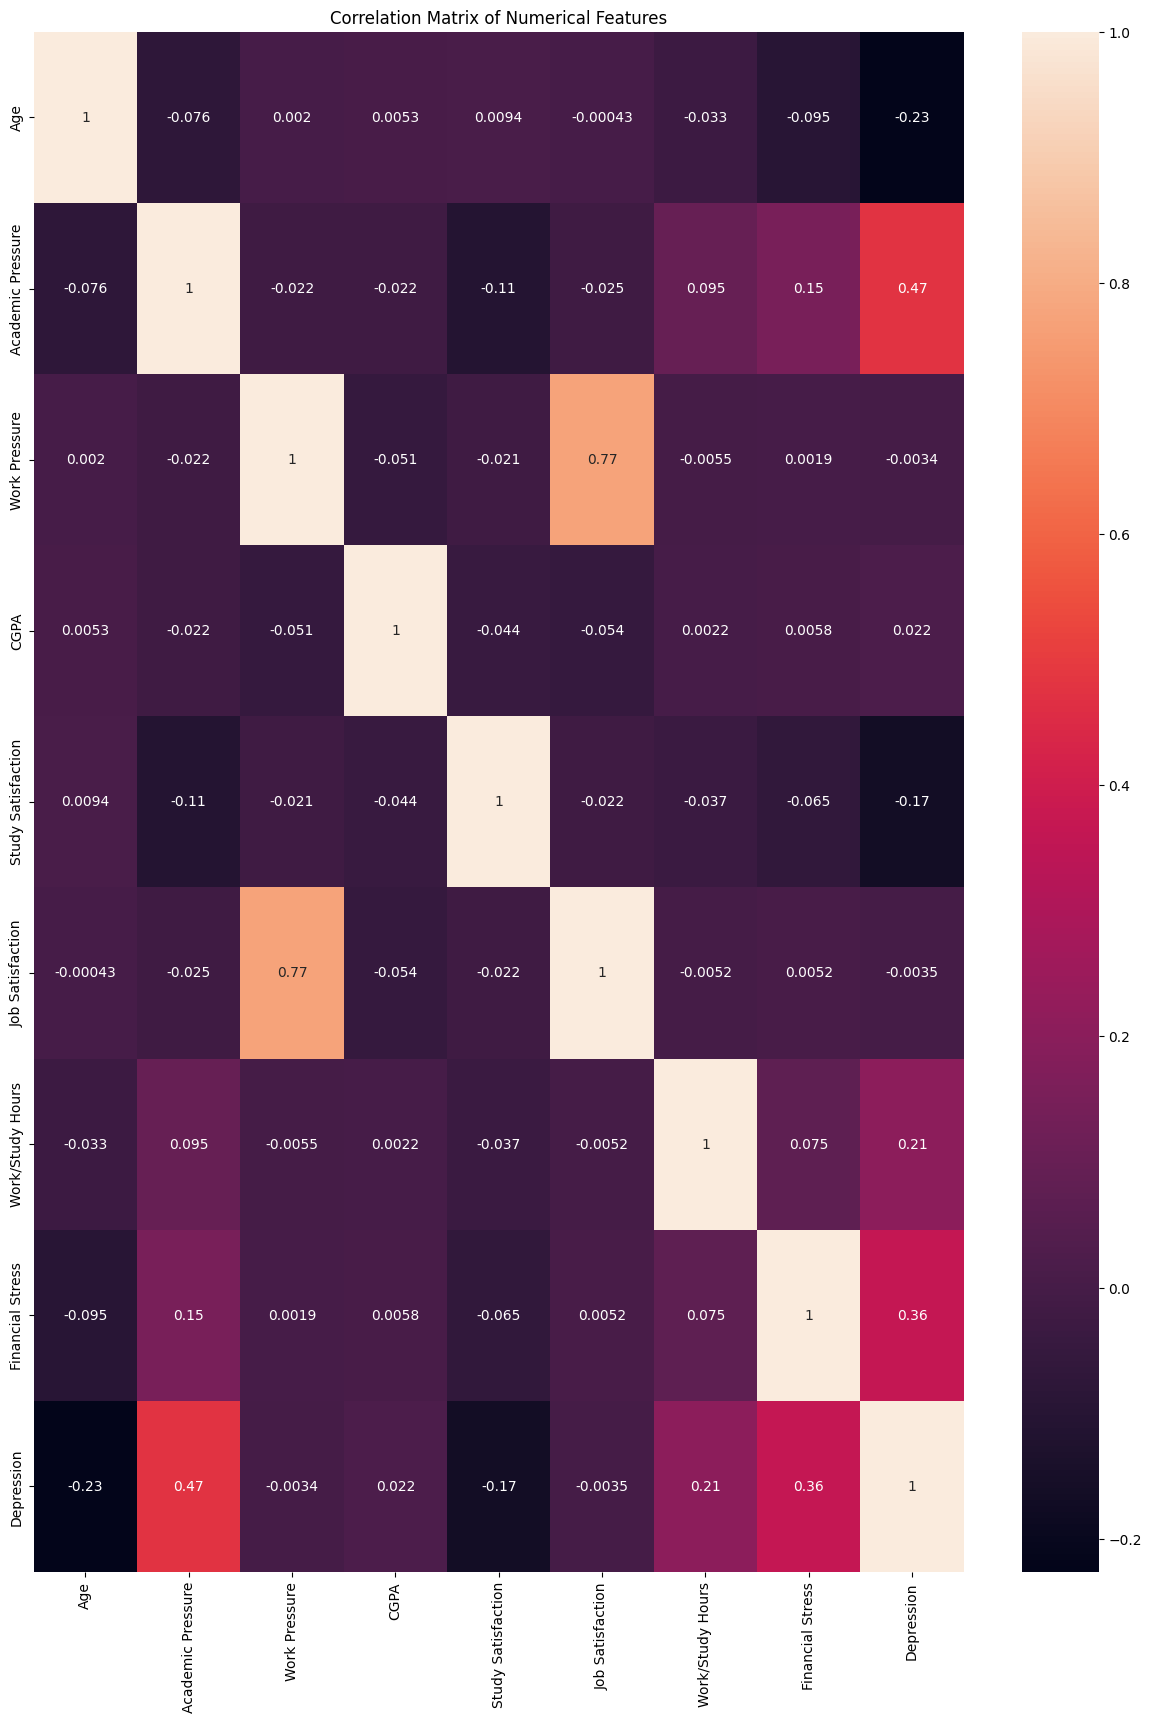

In [155]:
plt.figure(figsize=(15,20))
correlation_matrix= (df.select_dtypes(include='number').corr())
sns.heatmap(correlation_matrix, annot=True)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

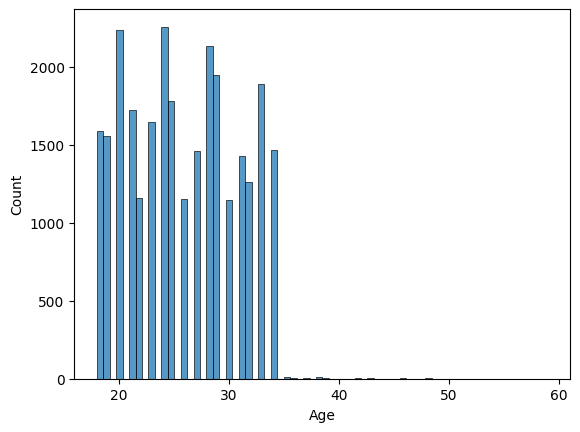

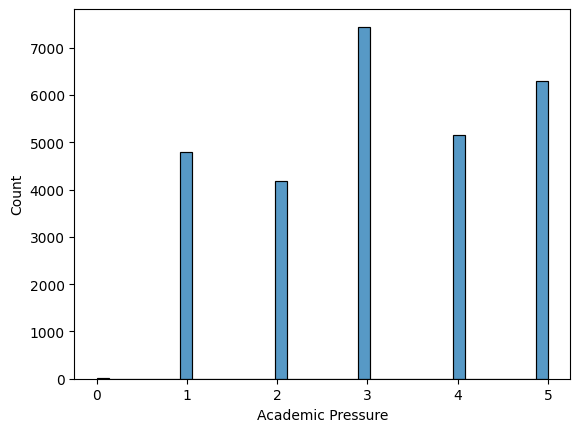

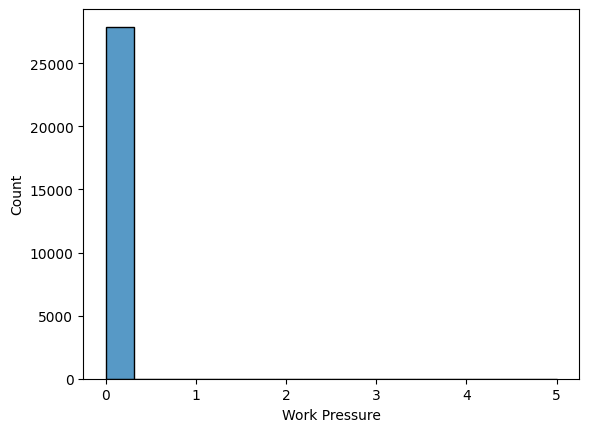

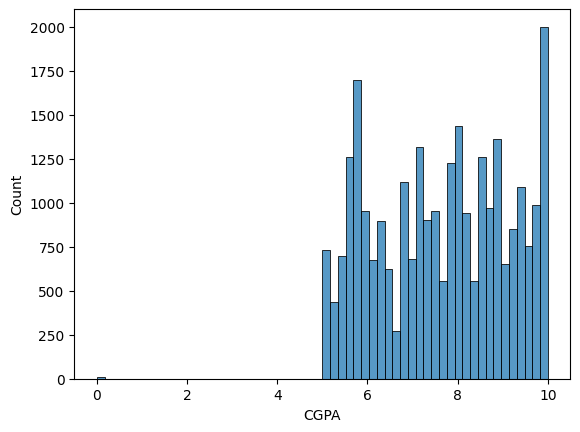

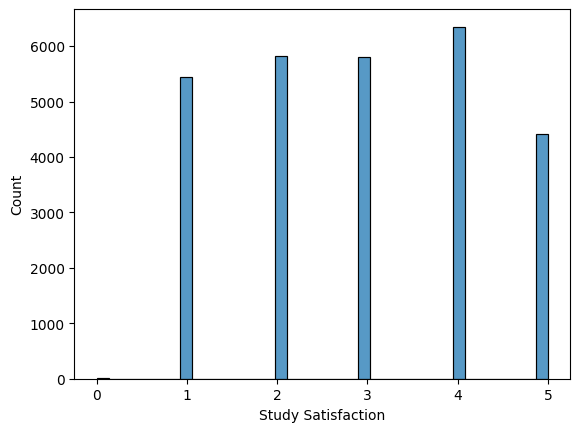

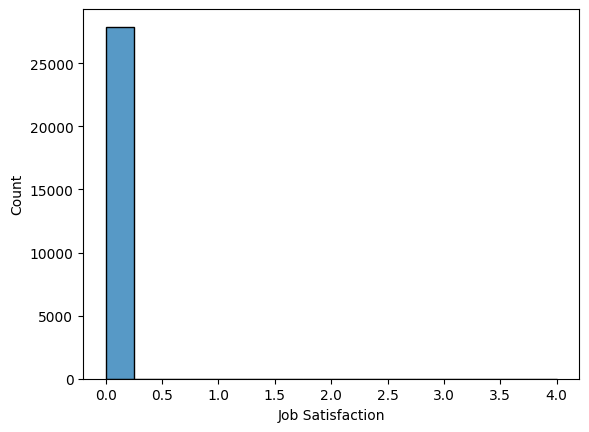

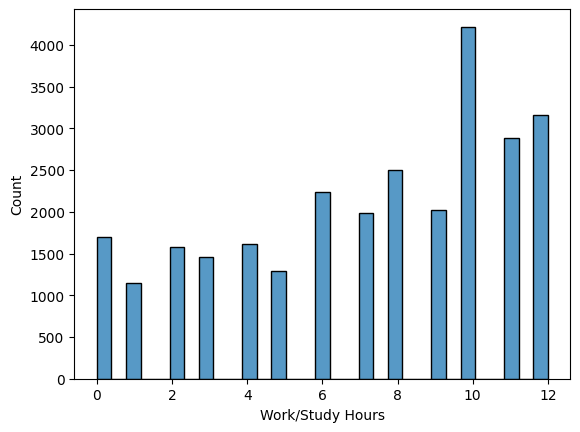

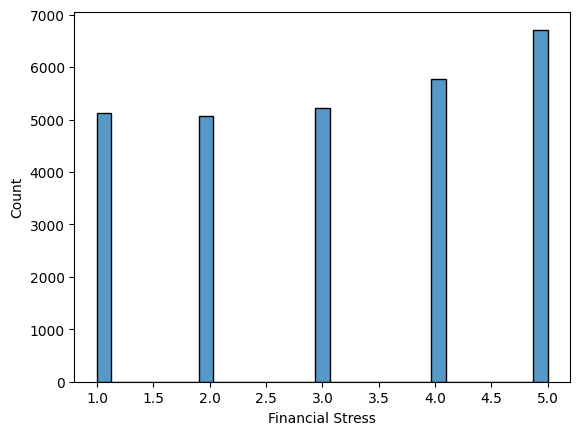

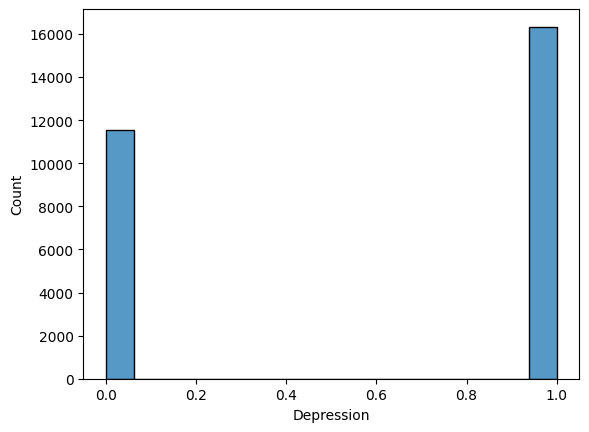

In [156]:
for i in df.select_dtypes(include='number').columns:
    sns.histplot(data=df,x=i)
    plt.show()

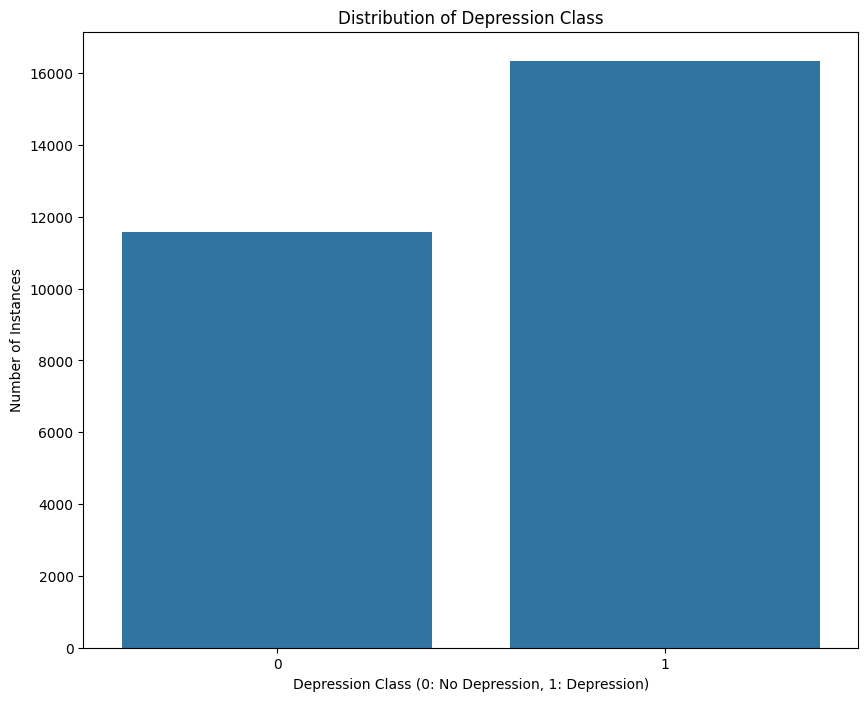

The classes are not balanced.


In [157]:
# Count the occurrences of each unique value in the 'Depression' column
Depression = df['Depression'].value_counts()

# Create a bar chart
plt.figure(figsize=(10, 8))
sns.barplot(x=Depression.index, y=Depression.values)
plt.title('Distribution of Depression Class')
plt.xlabel('Depression Class (0: No Depression, 1: Depression)')
plt.ylabel('Number of Instances')
plt.show()

# Print whether the classes are balanced
if len(Depression) > 1:
  if abs(Depression[0] - Depression[1]) < 10 :
     print("The classes are balanced.")
  else:
      print("The classes are not balanced.")
else:
    print("There is only one class in the output feature")

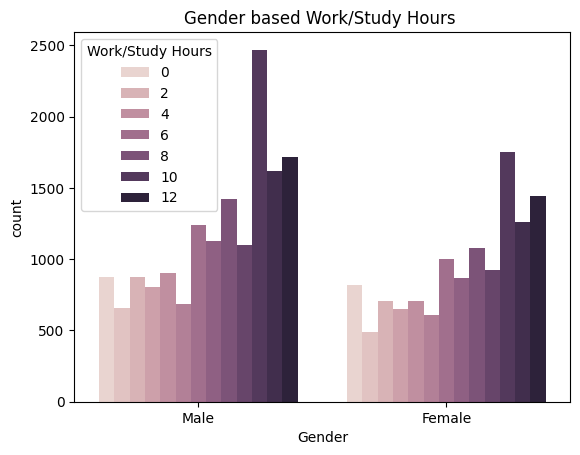

In [158]:
sns.countplot(x='Gender', hue='Work/Study Hours', data=df)
plt.title('Gender based Work/Study Hours ')
plt.show()

In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 17 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27901 non-null  object 
 1   Age                                    27901 non-null  int64  
 2   City                                   27901 non-null  object 
 3   Profession                             27901 non-null  object 
 4   Academic Pressure                      27859 non-null  float64
 5   Work Pressure                          27901 non-null  int64  
 6   CGPA                                   27859 non-null  float64
 7   Study Satisfaction                     27833 non-null  float64
 8   Job Satisfaction                       27901 non-null  int64  
 9   Sleep Duration                         27901 non-null  object 
 10  Dietary Habits                         27901 non-null  object 
 11  De

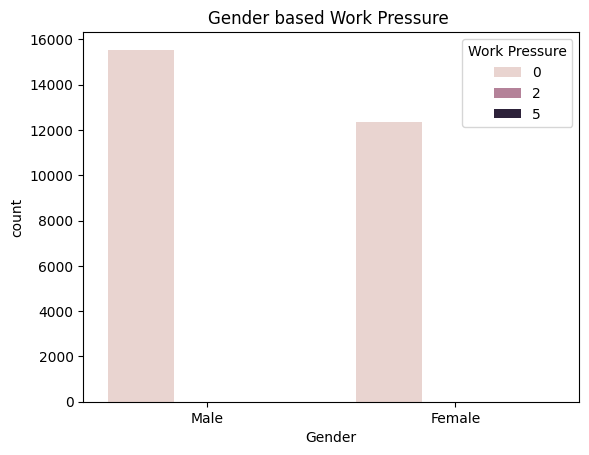

In [160]:
sns.countplot(x='Gender', hue='Work Pressure', data=df)
plt.title('Gender based Work Pressure ')
plt.show()

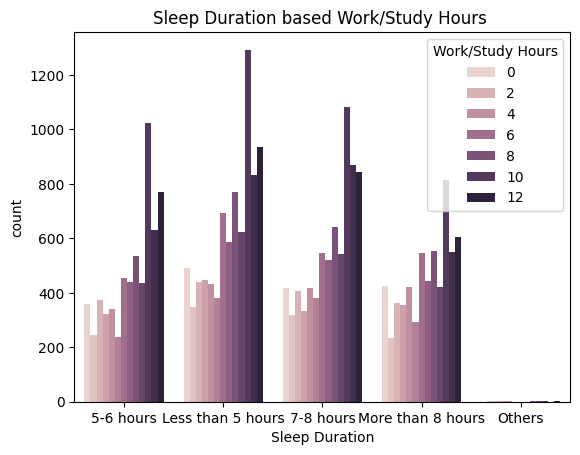

In [161]:
sns.countplot(x='Sleep Duration', hue='Work/Study Hours', data=df)
plt.title('Sleep Duration based Work/Study Hours ')
plt.show()

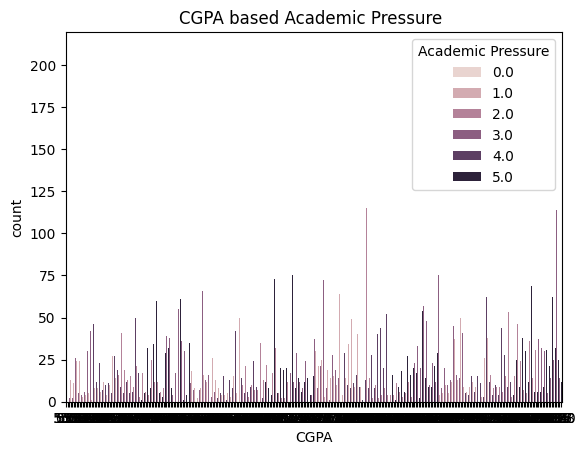

In [162]:
sns.countplot(x='CGPA', hue='Academic Pressure', data=df)
plt.title('CGPA based Academic Pressure ')
plt.show()

In [176]:
# Identify columns with NULL values
missing_values = df.isnull().sum()   #Null values in the dataset
print("Missing Values:")
print(missing_values)

# List of categorical features
categorical_features = ['Gender','City','Profession','Sleep Duration','Dietary Habits','Degree','Have you ever had suicidal thoughts ?',
                        'Family History of Mental Illness',]
print("\nCategorical Features:")
print(categorical_features)

Missing Values:
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

Categorical Features:
['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']


In [164]:
'''from sklearn.impute import KNNImputer
impute = KNNImputer()'''

'from sklearn.impute import KNNImputer\nimpute = KNNImputer()'

In [165]:
'''for x in df.select_dtypes(include='number').columns:
    df[x]=impute.fit_transform(df[[x]])'''

"for x in df.select_dtypes(include='number').columns:\n    df[x]=impute.fit_transform(df[[x]])"

In [166]:
#df.isnull().sum()

In [171]:
# 1. Impute 'Academic Pressure' with the median
median_imputer = SimpleImputer(strategy='median')
df['Academic Pressure'] = median_imputer.fit_transform(df[['Academic Pressure']])

median_imputer = SimpleImputer(strategy='median')
df['Financial Stress'] = median_imputer.fit_transform(df[['Financial Stress']])
# 2. Impute 'Work/Study Hours' with the mean
mean_imputer = SimpleImputer(strategy='mean')
df['Work/Study Hours'] = mean_imputer.fit_transform(df[['Work/Study Hours']])

mean_imputer = SimpleImputer(strategy='mean')
df['Study Satisfaction'] = mean_imputer.fit_transform(df[['Study Satisfaction']])

mean_imputer = SimpleImputer(strategy='mean')
df['CGPA'] = mean_imputer.fit_transform(df[['CGPA']])
# # 3. Impute 'stroke' with the most frequent value
# most_frequent_imputer = SimpleImputer(strategy='most_frequent')

In [172]:
df.isnull().sum()

,0
Gender,0
Age,0
City,0
Profession,0
Academic Pressure,0
Work Pressure,0
CGPA,0
Study Satisfaction,0
Job Satisfaction,0
Sleep Duration,0


In [173]:
'''#second method
encoding = LabelEncoder()
for i in df.columns:
  n = df[i].dtypes
  n = str(n)
  if n == 'object':
    df[i] = encoding.fit_transform(df[i])
df.info()
df.isnull().sum()'''

"#second method\nencoding = LabelEncoder()\nfor i in df.columns:\n  n = df[i].dtypes\n  n = str(n)\n  if n == 'object':\n    df[i] = encoding.fit_transform(df[i])\ndf.info()\ndf.isnull().sum()"

In [179]:
unique_values = df['Depression'].unique()
print("Unique values in 'Status':", unique_values)


Unique values in 'Status': [1. 0.]


In [180]:
level_encoding= LabelEncoder()
df['Status_Encoded'] = level_encoding.fit_transform(df['Depression'])
df


,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,Status_Encoded
0,1,0.365854,51,11,1.0,0.0,0.89700,0.400000,0.0,0,0,3,1,0.250000,0.00,0,1.0,1
1,0,0.146341,3,11,0.4,0.0,0.59000,0.588826,0.0,0,1,10,0,0.250000,0.25,1,0.0,0
2,1,0.317073,44,11,0.6,0.0,0.70300,1.000000,0.0,2,0,5,0,0.750000,0.00,1,0.0,0
3,0,0.243902,49,11,0.6,0.0,0.55900,0.400000,0.0,1,1,7,1,0.333333,1.00,1,1.0,1
4,0,0.170732,16,11,0.8,0.0,0.81300,0.600000,0.0,0,1,17,1,0.083333,0.00,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,0,0.219512,45,11,1.0,0.0,0.57500,0.588826,0.0,0,3,11,1,0.583333,0.00,1,0.0,0
27897,1,0.219512,25,11,0.4,0.0,0.94000,0.600000,0.0,2,0,25,0,0.000000,0.50,1,0.0,0
27898,1,0.317073,9,11,0.6,0.0,0.66100,0.800000,0.0,0,3,22,0,1.000000,0.25,0,0.0,0
27899,0,0.000000,25,11,1.0,0.0,0.76565,0.400000,0.0,2,0,11,1,0.596470,1.00,0,1.0,1


In [174]:
df.columns.tolist()

['Gender',
 'Age',
 'City',
 'Profession',
 'Academic Pressure',
 'Work Pressure',
 'CGPA',
 'Study Satisfaction',
 'Job Satisfaction',
 'Sleep Duration',
 'Dietary Habits',
 'Degree',
 'Have you ever had suicidal thoughts ?',
 'Work/Study Hours',
 'Financial Stress',
 'Family History of Mental Illness',
 'Depression']

In [175]:
# MinMaxScaler is used to scale numerical features to a range between 0 and 1.
# It preserves the original distribution of the data and is suitable for algorithms that benefit from scaled inputs.
numerical_features = ['Age','Academic Pressure','Work Pressure','CGPA','Study Satisfaction','Job Satisfaction','Work/Study Hours',
                      'Financial Stress','Depression']
scaler = MinMaxScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])

# Display the first few rows of the scaled dataset
print(df.head())

   Gender       Age  City  Profession  Academic Pressure  Work Pressure  \
0       1  0.365854    51          11                1.0            0.0   
1       0  0.146341     3          11                0.4            0.0   
2       1  0.317073    44          11                0.6            0.0   
3       0  0.243902    49          11                0.6            0.0   
4       0  0.170732    16          11                0.8            0.0   

    CGPA  Study Satisfaction  Job Satisfaction  Sleep Duration  \
0  0.897            0.400000               0.0               0   
1  0.590            0.588826               0.0               0   
2  0.703            1.000000               0.0               2   
3  0.559            0.400000               0.0               1   
4  0.813            0.600000               0.0               0   

   Dietary Habits  Degree  Have you ever had suicidal thoughts ?  \
0               0       3                                      1   
1               

In [181]:
#we will implement one hot encoding for country column
df['CGPA'].value_counts()

,count
CGPA,
0.804,821
0.996,425
0.574,410
0.895,369
0.921,343
...,...
0.765,1
0.742,1
0.826,1


In [182]:
df_one_hot = pd.get_dummies(df, columns=['CGPA'], drop_first=True)
df_one_hot.head()

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,...,CGPA_0.9900000000000001,CGPA_0.9910000000000001,CGPA_0.992,CGPA_0.993,CGPA_0.994,CGPA_0.995,CGPA_0.9960000000000001,CGPA_0.9970000000000001,CGPA_0.9980000000000001,CGPA_1.0
0,1,0.365854,51,11,1.0,0.0,0.400000,0.0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,0,0.146341,3,11,0.4,0.0,0.588826,0.0,0,1,...,False,False,False,False,False,False,False,False,False,False
2,1,0.317073,44,11,0.6,0.0,1.000000,0.0,2,0,...,False,False,False,False,False,False,False,False,False,False
3,0,0.243902,49,11,0.6,0.0,0.400000,0.0,1,1,...,False,False,False,False,False,False,False,False,False,False
4,0,0.170732,16,11,0.8,0.0,0.600000,0.0,0,1,...,False,False,False,False,False,False,False,False,False,False


In [183]:
#dropping columns
#df.drop(['Family History of Mental Illness'], axis=1)

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Depression,Status_Encoded
0,1,0.365854,51,11,1.0,0.0,0.89700,0.400000,0.0,0,0,3,1,0.250000,0.00,1.0,1
1,0,0.146341,3,11,0.4,0.0,0.59000,0.588826,0.0,0,1,10,0,0.250000,0.25,0.0,0
2,1,0.317073,44,11,0.6,0.0,0.70300,1.000000,0.0,2,0,5,0,0.750000,0.00,0.0,0
3,0,0.243902,49,11,0.6,0.0,0.55900,0.400000,0.0,1,1,7,1,0.333333,1.00,1.0,1
4,0,0.170732,16,11,0.8,0.0,0.81300,0.600000,0.0,0,1,17,1,0.083333,0.00,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,0,0.219512,45,11,1.0,0.0,0.57500,0.588826,0.0,0,3,11,1,0.583333,0.00,0.0,0
27897,1,0.219512,25,11,0.4,0.0,0.94000,0.600000,0.0,2,0,25,0,0.000000,0.50,0.0,0
27898,1,0.317073,9,11,0.6,0.0,0.66100,0.800000,0.0,0,3,22,0,1.000000,0.25,0.0,0
27899,0,0.000000,25,11,1.0,0.0,0.76565,0.400000,0.0,2,0,11,1,0.596470,1.00,1.0,1


In [189]:
#Data Set Splitting
# Separate features (X) and target variable (y)
X = df.drop(['Academic Pressure','Work Pressure','Have you ever had suicidal thoughts ?',
            'Work/Study Hours','Financial Stress','Family History of Mental Illness'], axis=1)
y = df['Depression']

# Split the dataset into training and testing sets using stratified sampling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Print the shapes of the resulting sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (19530, 12)
X_test shape: (8371, 12)
y_train shape: (19530,)
y_test shape: (8371,)


In [192]:
ml_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(),
    "LightGBM": LGBMRegressor(),

}

In [193]:
for model_name, model in ml_models.items():
    print(f"\nTraining {model_name}...")

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Results for {model_name}:")
    print(f"Mean Absolute Error: {mae}")
    print(f"Mean Squared Error: {mse}")
    print(f"R2 Score: {r2}")


Training Linear Regression...
Results for Linear Regression:
Mean Absolute Error: 7.284381017341133e-16
Mean Squared Error: 7.589021628905952e-31
R2 Score: 1.0

Training Decision Tree...
Results for Decision Tree:
Mean Absolute Error: 0.0
Mean Squared Error: 0.0
R2 Score: 1.0

Training Random Forest...
Results for Random Forest:
Mean Absolute Error: 0.0
Mean Squared Error: 0.0
R2 Score: 1.0

Training Gradient Boosting...
Results for Gradient Boosting:
Mean Absolute Error: 1.2892435140514514e-05
Mean Squared Error: 1.7122271674464946e-10
R2 Score: 0.9999999992944921

Training XGBoost...
Results for XGBoost:
Mean Absolute Error: 5.444321345979781e-06
Mean Squared Error: 3.0533659151055874e-11
R2 Score: 0.9999999998741887

Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001579 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if

<ipython-input-194-c10a563e09a1>:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(results_df["Model"], rotation=45, ha='right')
<ipython-input-194-c10a563e09a1>:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(results_df["Model"], rotation=45, ha='right')
<ipython-input-194-c10a563e09a1>:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(results_df["Model"], rotation=45, ha='right')


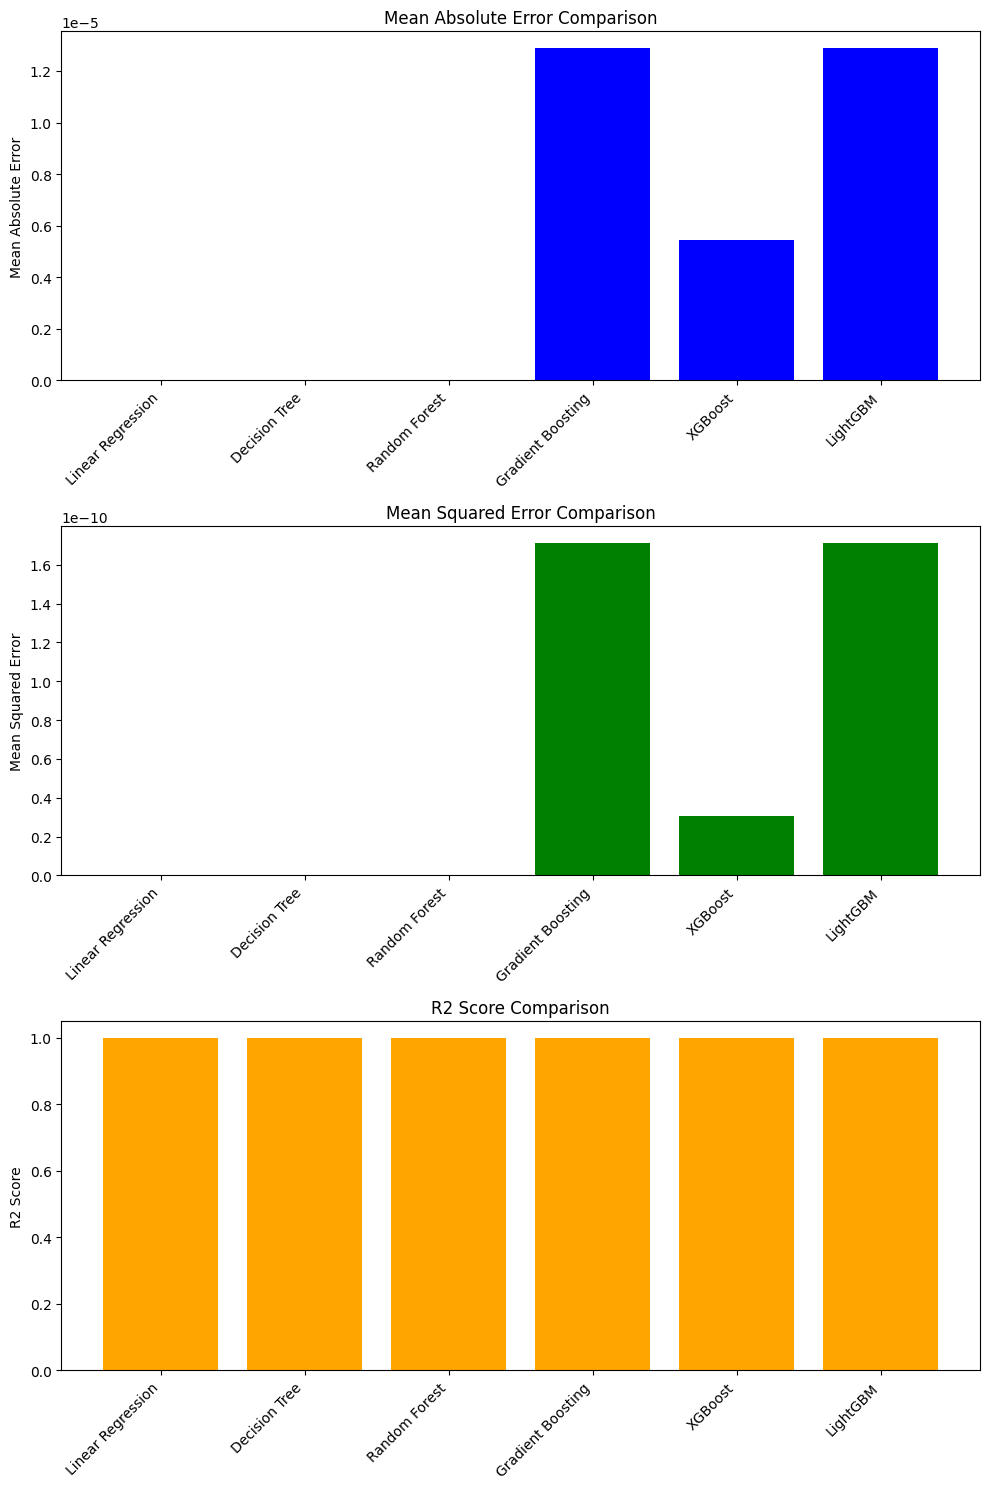

In [194]:

results = {
    "Model": [],
    "Mean Absolute Error": [],
    "Mean Squared Error": [],
    "R2 Score": []
}


for model_name, model in ml_models.items():
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results["Model"].append(model_name)
    results["Mean Absolute Error"].append(mae)
    results["Mean Squared Error"].append(mse)
    results["R2 Score"].append(r2)

# Convert the results to a DataFrame
results_df = pd.DataFrame(results)

# Plot the bar chart
fig, ax = plt.subplots(3, 1, figsize=(10, 15))

# Plot MAE
ax[0].bar(results_df["Model"], results_df["Mean Absolute Error"], color='blue')
ax[0].set_title('Mean Absolute Error Comparison')
ax[0].set_ylabel('Mean Absolute Error')
ax[0].set_xticklabels(results_df["Model"], rotation=45, ha='right')

# Plot MSE
ax[1].bar(results_df["Model"], results_df["Mean Squared Error"], color='green')
ax[1].set_title('Mean Squared Error Comparison')
ax[1].set_ylabel('Mean Squared Error')
ax[1].set_xticklabels(results_df["Model"], rotation=45, ha='right')

# Plot R2 Score
ax[2].bar(results_df["Model"], results_df["R2 Score"], color='orange')
ax[2].set_title('R2 Score Comparison')
ax[2].set_ylabel('R2 Score')
ax[2].set_xticklabels(results_df["Model"], rotation=45, ha='right')

plt.tight_layout()
plt.show()

Accuracy: 0.9919
Precision: 0.9919
Recall: 0.9919

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      3470
         1.0       0.99      1.00      0.99      4901

    accuracy                           0.99      8371
   macro avg       0.99      0.99      0.99      8371
weighted avg       0.99      0.99      0.99      8371



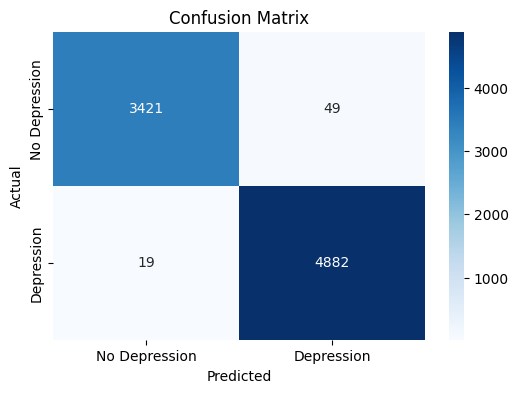

In [196]:
# Initialize the KNN classifier with k=5
knn_classifier = KNeighborsClassifier(n_neighbors=5)
# Train the KNN classifier
knn_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Calculate precision and recall - KNN
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)

# Print the results
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
KNN_score=[accuracy,precision,recall]
# Visualize confusion matrix using a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['No Depression', 'Depression'], yticklabels=['No Depression', 'Depression'])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

Accuracy (Decision Tree): 1.0000
Precision (Decision Tree): 1.0000
Recall (Decision Tree): 1.0000

Classification Report (Decision Tree):
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3470
         1.0       1.00      1.00      1.00      4901

    accuracy                           1.00      8371
   macro avg       1.00      1.00      1.00      8371
weighted avg       1.00      1.00      1.00      8371



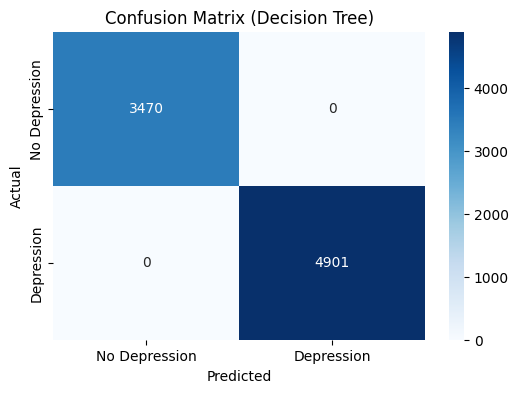

In [197]:
# Initialize the Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters here

# Train the Decision Tree classifier
dt_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_classifier.predict(X_test)

# Evaluate the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy (Decision Tree): {accuracy_dt:.4f}")

# Calculate precision and recall - Decision Tree
precision_dt = precision_score(y_test, y_pred_dt, average='weighted', zero_division=0)
recall_dt = recall_score(y_test, y_pred_dt, average='weighted', zero_division=0)

# Print the results
print(f"Precision (Decision Tree): {precision_dt:.4f}")
print(f"Recall (Decision Tree): {recall_dt:.4f}")

# Print classification report
print("\nClassification Report (Decision Tree):")
print(classification_report(y_test, y_pred_dt))

# Confusion Matrix
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
DT_score = [accuracy_dt, precision_dt, recall_dt]
# Visualize confusion matrix using a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_dt, annot=True, fmt="d", cmap="Blues", xticklabels=['No Depression', 'Depression'], yticklabels=['No Depression', 'Depression'])
plt.title("Confusion Matrix (Decision Tree)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

Accuracy (Naive Bayes): 1.0000
Precision (Naive Bayes): 1.0000
Recall (Naive Bayes): 1.0000

Classification Report (Naive Bayes):
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3470
         1.0       1.00      1.00      1.00      4901

    accuracy                           1.00      8371
   macro avg       1.00      1.00      1.00      8371
weighted avg       1.00      1.00      1.00      8371



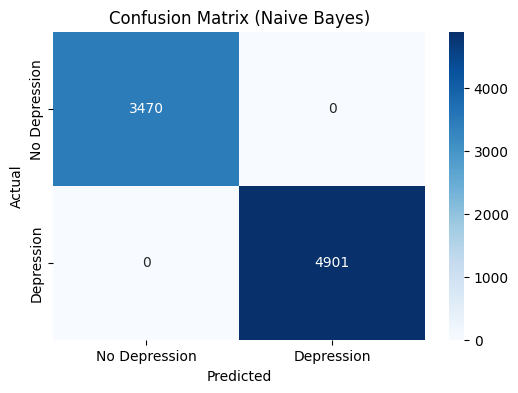

In [198]:
from sklearn.naive_bayes import GaussianNB

# Initialize the Gaussian Naive Bayes classifier
nb_classifier = GaussianNB()

# Train the Naive Bayes classifier
nb_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_nb = nb_classifier.predict(X_test)

# Evaluate the model
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Accuracy (Naive Bayes): {accuracy_nb:.4f}")

# Calculate precision and recall
precision_nb = precision_score(y_test, y_pred_nb, average='weighted', zero_division=0)
recall_nb = recall_score(y_test, y_pred_nb, average='weighted', zero_division=0)

print(f"Precision (Naive Bayes): {precision_nb:.4f}")
print(f"Recall (Naive Bayes): {recall_nb:.4f}")

print("\nClassification Report (Naive Bayes):")
print(classification_report(y_test, y_pred_nb, zero_division=0))

# Confusion Matrix
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)

# Visualize confusion matrix using a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_nb, annot=True, fmt="d", cmap="Blues", xticklabels=['No Depression', 'Depression'], yticklabels=['No Depression', 'Depression'])
plt.title("Confusion Matrix (Naive Bayes)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (3,) and arg 1 with shape (2,).

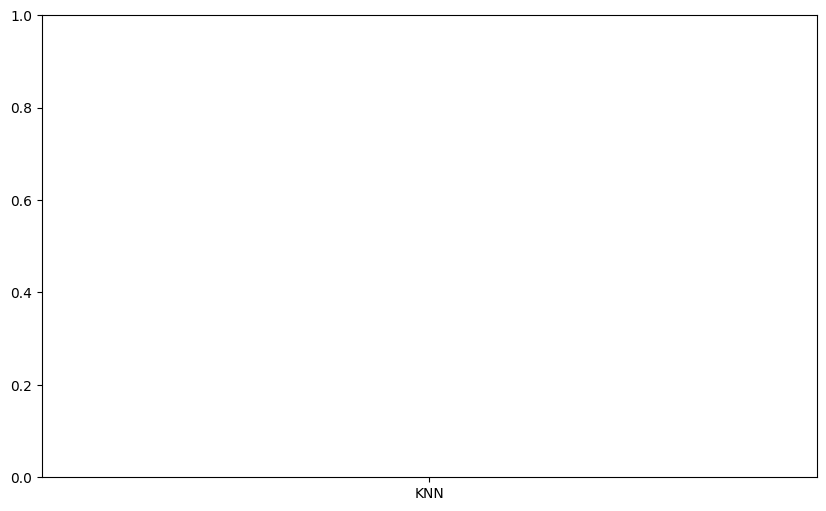

In [201]:
'''model_names = ['KNN', 'Decision Tree', 'Naive Bayes']
accuracy_scores = [KNN_score[0], DT_score[0]]#, naive_bayes_score[0]]
accuracy_score_with_100 = []
for i in range(len(accuracy_scores)):
    accuracy_score_with_100.append(accuracy_scores[i]*100)

plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracy_score_with_100, color=['Black', 'red'])#, 'gold'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Comparison of Model Accuracy")
plt.ylim(0, 100)  # Set y-axis limit to 0-1 for accuracy
plt.show()'''

In [ ]:
'''# Precision and Recall Comparison
models = ['KNN', 'Decision Tree','Naive Bayes']
precision_scores = [KNN_score[1], DT_score[1], NB_score[1]]
recall_scores = [KNN_score[2], DT_score[2], NB_score[2]]


# Create the plot
x = range(len(models))
width = 0.35

fig, ax1 = plt.subplots(figsize=(12, 6))

rects1 = ax1.bar([i - width/2 for i in x], precision_scores, width, label='Precision', color='gold')
rects2 = ax1.bar([i + width/2 for i in x], recall_scores, width, label='Recall', color='black')

ax1.set_xlabel('Models')
ax1.set_ylabel('Scores')
ax1.set_title('Precision and Recall Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend()
plt.show()'''